<a href="https://colab.research.google.com/github/smritipioneer/Vendor-procurement-project/blob/main/procurement_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step 1: Load Data

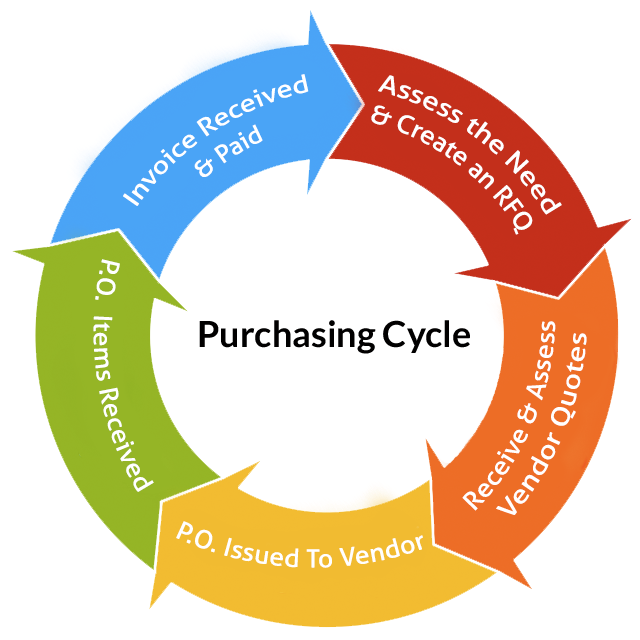

In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/project LR/Procurement KPI Analysis Dataset with formula.csv")

print(df.head())
print(df.info())

      PO_ID         Supplier  Order_Date Delivery_Date    Item_Category  \
0  PO-00001        Alpha_Inc  17-10-2023    25-10-2023  Office Supplies   
1  PO-00002  Delta_Logistics  25-04-2022    05-05-2022  Office Supplies   
2  PO-00003         Gamma_Co  26-01-2022    15-02-2022              MRO   
3  PO-00004    Beta_Supplies  09-10-2022    28-10-2022        Packaging   
4  PO-00005  Delta_Logistics  08-09-2022    20-09-2022    Raw Materials   

  Order_Status  Quantity  Unit_Price  Negotiated_Price  Defective_Units  \
0    Cancelled      1176       20.13             17.81              NaN   
1    Delivered      1509       39.32             37.34            235.0   
2    Delivered       910       95.51             92.26             41.0   
3    Delivered      1344       99.85             95.52            112.0   
4    Delivered      1180       64.07             60.53            171.0   

  Compliance  Total Spend  Delivery Days Order Month  Negotiation Savings  \
0        Yes     2367

Step 2: Data Cleaning

In [ ]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['Delivery_Date'] = pd.to_datetime(df['Delivery_Date'])

/tmp/ipykernel_2227/2112003661.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Order_Date'] = pd.to_datetime(df['Order_Date'])
/tmp/ipykernel_2227/2112003661.py:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Delivery_Date'] = pd.to_datetime(df['Delivery_Date'])


In [ ]:
df.isnull().sum()

,0
PO_ID,0
Supplier,0
Order_Date,0
Delivery_Date,87
Item_Category,0
Order_Status,0
Quantity,0
Unit_Price,0
Negotiated_Price,0
Defective_Units,136


In [ ]:
df.fillna(0, inplace=True)

/tmp/ipykernel_2227/4231983114.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0' has dtype incompatible with datetime64[ns], please explicitly cast to a compatible dtype first.
  df.fillna(0, inplace=True)


Step 3: Create Procurement KPIs
Total Spend

In [ ]:
df['Total_Spend'] = (
    df['Quantity']
    * df['Unit_Price']
)

In [ ]:
df['Savings'] = (
    (df['Unit_Price']
     - df['Negotiated_Price'])
    * df['Quantity']
)

Delivery Days

In [ ]:
df['Delivery_Days'] = (
    pd.to_datetime(df['Delivery_Date'], errors='coerce')
    - pd.to_datetime(df['Order_Date'], errors='coerce')
).dt.days

PO Age

For open orders:

In [ ]:
today = pd.Timestamp.today()

df['PO_Age'] = (
    today
    - df['Order_Date']
).dt.days

Step 4: Open vs Closed Orders
Open PO Count

In [ ]:
open_po = df[
    df['Order_Status'] == 'Open'
]

print(len(open_po))

0


Open PO Value

In [ ]:
open_value = open_po[
    'Total_Spend'
].sum()

print(open_value)

0.0


Step 5: Quantity Validation
Average Quantity by Category

In [ ]:
avg_qty = df.groupby(
    'Item_Category'
)['Quantity'].mean()

merge back

In [ ]:
df['Avg_Qty'] = df.groupby(
    'Item_Category'
)['Quantity'].transform('mean')

Variance:

In [ ]:
df['Qty_Variance_%'] = (
(
df['Quantity']
-
df['Avg_Qty']
)
/
df['Avg_Qty']
) * 100

In [ ]:
df['Qty_Risk'] = df[
    'Qty_Variance_%'
].apply(
lambda x:
'High'
if x > 25
else 'Normal'
)

Step 6: Price Validation

Average Price:

In [ ]:
df['Avg_Price'] = df.groupby(
    'Item_Category'
)['Unit_Price'].transform('mean')

Variance

In [ ]:
df['Price_Variance_%'] = (
(
df['Unit_Price']
-
df['Avg_Price']
)
/
df['Avg_Price']
)*100

risk

In [ ]:
df['Price_Risk'] = df[
    'Price_Variance_%'
].apply(
lambda x:
'High'
if x > 10
else 'Normal'
)

In [ ]:
Step 7: Supplier Delivery Efficiency

In [ ]:
delivery_perf = (
df.groupby('Supplier')
['Delivery_Days']
.mean()
.sort_values()
)

print(delivery_perf)

Supplier
Alpha_Inc         -3273.276596
Delta_Logistics   -2246.912281
Epsilon_Group     -1970.795181
Gamma_Co          -1753.300699
Beta_Supplies     -1605.634615
Name: Delivery_Days, dtype: float64


Step 8: Supplier Quality KPI

In [ ]:
quality = (
df.groupby('Supplier')
.agg(
{
'Defective_Units':'sum',
'Quantity':'sum'
}
)
)

quality['Defect_Rate'] = (
quality['Defective_Units']
/
quality['Quantity']
)*100

print(quality)

                 Defective_Units  Quantity  Defect_Rate
Supplier                                               
Alpha_Inc                 2717.0    150414     1.806348
Beta_Supplies            13838.0    180516     7.665802
Delta_Logistics          19678.0    181652    10.832801
Epsilon_Group             4682.0    180053     2.600345
Gamma_Co                  7034.0    157916     4.454267


Step 9: Compliance %

In [ ]:
compliance = (
df.groupby('Supplier')
['Compliance']
.apply(
lambda x:
(x=='Yes').mean()*100
)
)

print(compliance)

Supplier
Alpha_Inc          93.617021
Beta_Supplies      75.641026
Delta_Logistics    60.818713
Epsilon_Group      98.192771
Gamma_Co           86.013986
Name: Compliance, dtype: float64


Step 10: Open PO Ageing

In [ ]:
def ageing_bucket(days):

    if days <= 7:
        return '0-7'

    elif days <= 15:
        return '8-15'

    elif days <= 30:
        return '16-30'

    else:
        return '30+'

df['Age_Bucket'] = (
df['PO_Age']
.apply(ageing_bucket)
)

In [ ]:
df.groupby(
'Age_Bucket'
)['PO_ID'].count()

,PO_ID
Age_Bucket,
30+,777


Step 11: Critical Pending Orders

In [ ]:
df['Critical_Order'] = (
(
df['Total_Spend']
> 100000
)
&
(
df['PO_Age']
> 15
)
)

In [ ]:
critical = df[
df['Critical_Order']
]

In [ ]:
Step 12: Backdated Orders

In [ ]:
backdated = df[
    pd.to_datetime(df['Delivery_Date'], errors='coerce')
    <
    pd.to_datetime(df['Order_Date'], errors='coerce')
]

In [ ]:
len(backdated)

88

Step 13: High Risk Orders

Combine rules:

In [ ]:
df['Risk_Flag'] = 'Normal'

df.loc[
(
(df['Price_Variance_%'] > 10)
|
(df['Qty_Variance_%'] > 25)
|
(df['Compliance'] == 'No')
|
(df['PO_Age'] > 30)
),
'Risk_Flag'
] = 'High Risk'

Step 14: Create KPI Summary Table

In [ ]:
kpi = {

'Total Spend':
df['Total_Spend'].sum(),

'Total Savings':
df['Savings'].sum(),

'Open PO Count':
len(
df[
df['Order_Status']=='Open'
]
),

'High Risk Orders':
len(
df[
df['Risk_Flag']
=='High Risk'
]
),

'Open PO Value':
df[
df['Order_Status']=='Open'
]['Total_Spend'].sum()

}

print(kpi)

{'Total Spend': np.float64(49304822.86), 'Total Savings': np.float64(3931126.4699999997), 'Open PO Count': 0, 'High Risk Orders': 777, 'Open PO Value': np.float64(0.0)}


Step 15: Charts with Matplotlib
Monthly Spend Trend

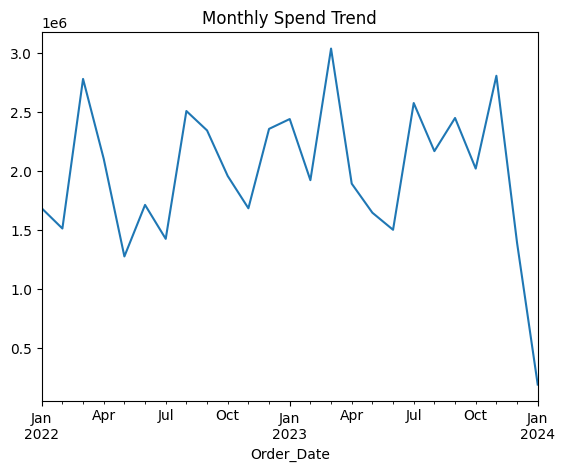

In [ ]:
import matplotlib.pyplot as plt

monthly = (
df.groupby(
df['Order_Date']
.dt.to_period('M')
)
['Total_Spend']
.sum()
)

monthly.plot()

plt.title(
'Monthly Spend Trend'
)

plt.show()

Top Vendors

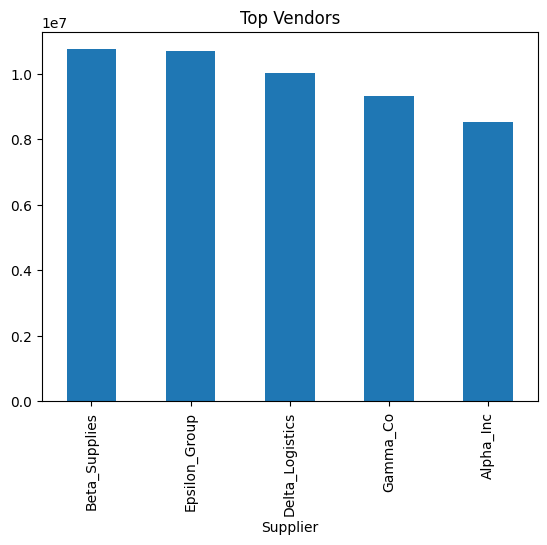

In [ ]:
vendor = (
df.groupby('Supplier')
['Total_Spend']
.sum()
.sort_values(
ascending=False
)
.head(10)
)

vendor.plot(
kind='bar'
)

plt.title(
'Top Vendors'
)

plt.show()

Step 16: Export for Tableau

In [ ]:
df.to_csv(
'Procurement_Final.csv',
index=False
)

In [ ]:
import os

output_path = "/content/drive/MyDrive/ProcurementProject/Procurement_Final.csv"
directory = os.path.dirname(output_path)

# Create the directory if it does not exist
os.makedirs(directory, exist_ok=True)

df.to_csv(output_path, index=False)

print("File saved successfully")

File saved successfully
